# Evaluation for ANN with strong arsenic contamination

In [7]:
from pathlib import Path
import sys
import torch

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_strong_contamination_paths, split_train_test
from src.event_detection_pipeline.model_io import load_detector, save_detector

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection_pipeline.evaluation import (
    plot_roc_curve_event_detection,
    plot_chlorine_prediction_quality,
    plot_precision_recall_curve,
    aggregate_evaluation_summary,
)

In [8]:
data_dir = ROOT / 'src' / 'data'
paths = collect_strong_contamination_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 16 | Test files: 4


In [9]:
print("Test:", len(test_paths))

for path in test_paths:
    print(path.name)

Test: 4
scada_data_strong_cont12.npz
scada_data_strong_cont13.npz
scada_data_strong_cont11.npz
scada_data_strong_cont10.npz


In [ ]:
history = 48
# history 48 = 1 day
epochs = 60
batch_size = 128
learning_rate = 3e-4
dropout = 0.0
weight_decay = 1e-4
early_stopping_patience = 8
max_validation_false_alarm_rate = 0.2

candidate_hidden_sizes = [
    (128, 64, 32),
]

In [29]:
# RUN only if you want to overwrite the current detector performance results

for hidden_sizes in candidate_hidden_sizes:
    candidate_detector = build_detector(
        train_paths,
        history=history,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        hidden_sizes=hidden_sizes,
        classifier_hidden_sizes=(32,),
        dropout=dropout,
        weight_decay=weight_decay,
        early_stopping_patience=early_stopping_patience,
        max_validation_false_alarm_rate=max_validation_false_alarm_rate,
    )

    save_detector(candidate_detector, directory=f"../../results/ANN/detector_strong_{'-'.join(map(str, hidden_sizes))}")


All files saved to /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_128-64-32/


In [11]:
def plot_metrics(result, title_prefix="", chlorine_indices=None):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Confusion Matrix
    cm = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Event"],
    )
    disp.plot(
        ax=axes[0, 0],
        colorbar=False,
        values_format=".2f",
    )
    axes[0, 0].set_title(f"{title_prefix}Confusion Matrix")

    # 2. Event detection ROC
    plot_roc_curve_event_detection(
        result,
        title=f"{title_prefix}Event Detection ROC",
        ax=axes[0, 1],
    )

    # 3. True chlorine regression quality (ROC would measure event residuals)
    plot_chlorine_prediction_quality(
        result,
        chlorine_indices=chlorine_indices,
        title=f"{title_prefix}Chlorine Prediction Quality",
        ax=axes[1, 0],
    )
    # Show the symmetric interval containing 95% of absolute prediction errors.
    selected_indices = (
        list(range(result.actual.shape[1]))
        if chlorine_indices is None else chlorine_indices
    )
    y_true = result.actual[:, selected_indices].reshape(-1)
    y_pred = result.predicted[:, selected_indices].reshape(-1)
    margin_95 = np.percentile(np.abs(y_pred - y_true), 95)
    x_line = np.linspace(
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max()),
        200,
    )
    axes[1, 0].fill_between(
        x_line, x_line - margin_95, x_line + margin_95,
        color="teal", alpha=0.15,
        label=f"95% error bound (±{margin_95:.3f})",
    )
    axes[1, 0].legend(loc="lower right")

    # 4. Precision-Recall curve
    plot_precision_recall_curve(
        result,
        title=f"{title_prefix}Precision-Recall Curve",
        ax=axes[1, 1],
    )

    plt.tight_layout()
    plt.show()
    return fig, axes


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_128-64-32/


,precision,recall,specificity,balanced_accuracy,accuracy,f1_score,roc_auc,average_precision,false_alarm_rate,detection_latency_seconds,chlorine_mae,chlorine_rmse,chlorine_r2,classifier_hidden_sizes
regressor_hidden_sizes,,,,,,,,,,,,,,
128-64-32,0.396505,0.449695,0.859159,0.654427,0.789282,0.421429,0.728228,0.492366,0.140841,5400.0,0.022738,0.047576,0.90982,32


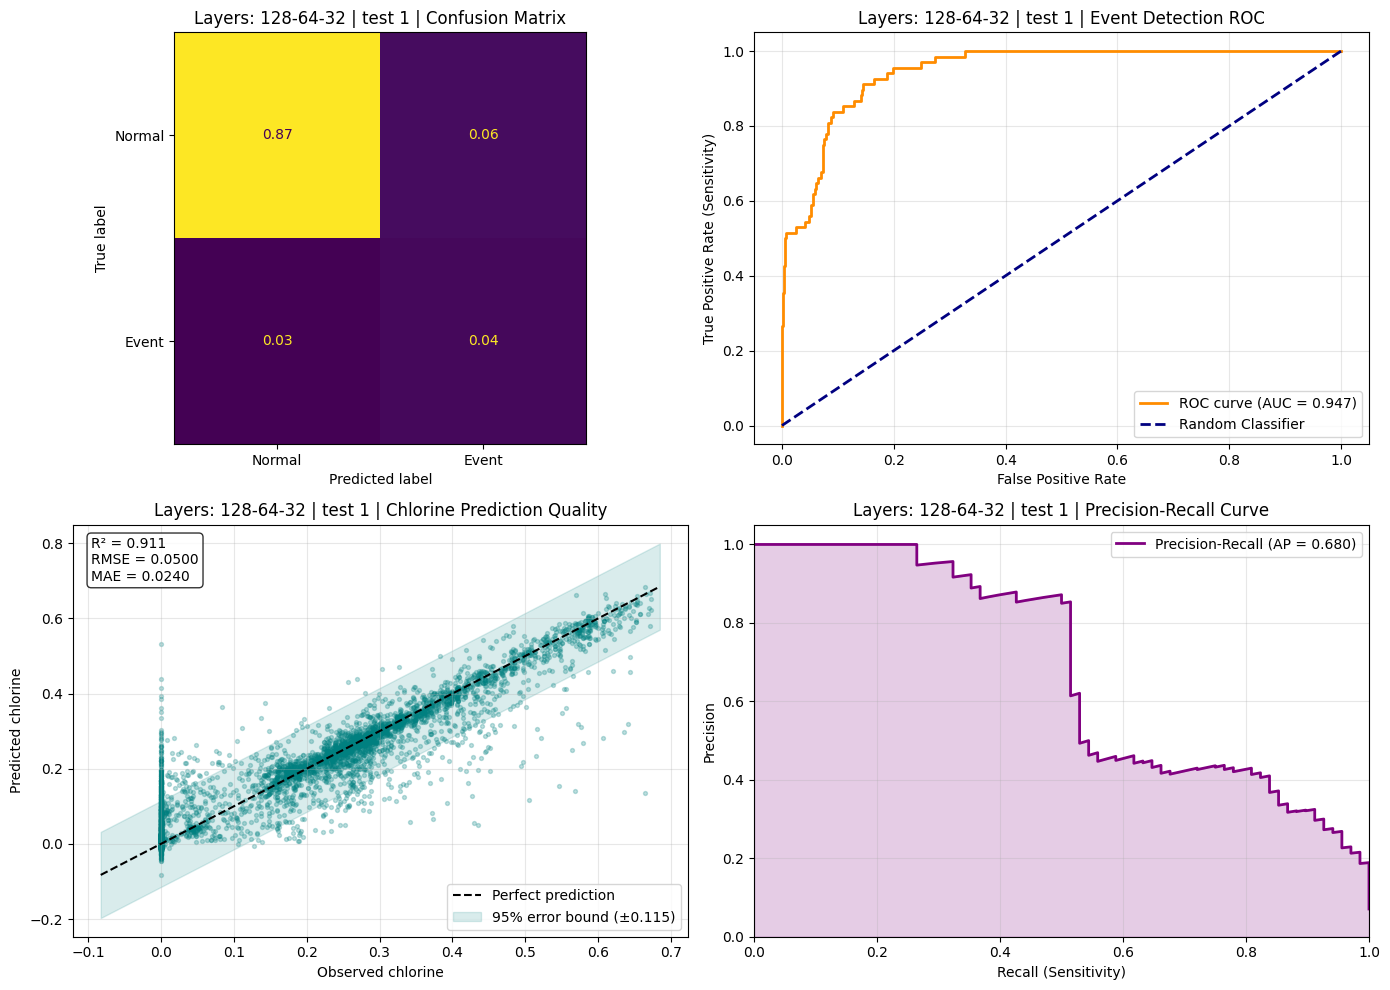

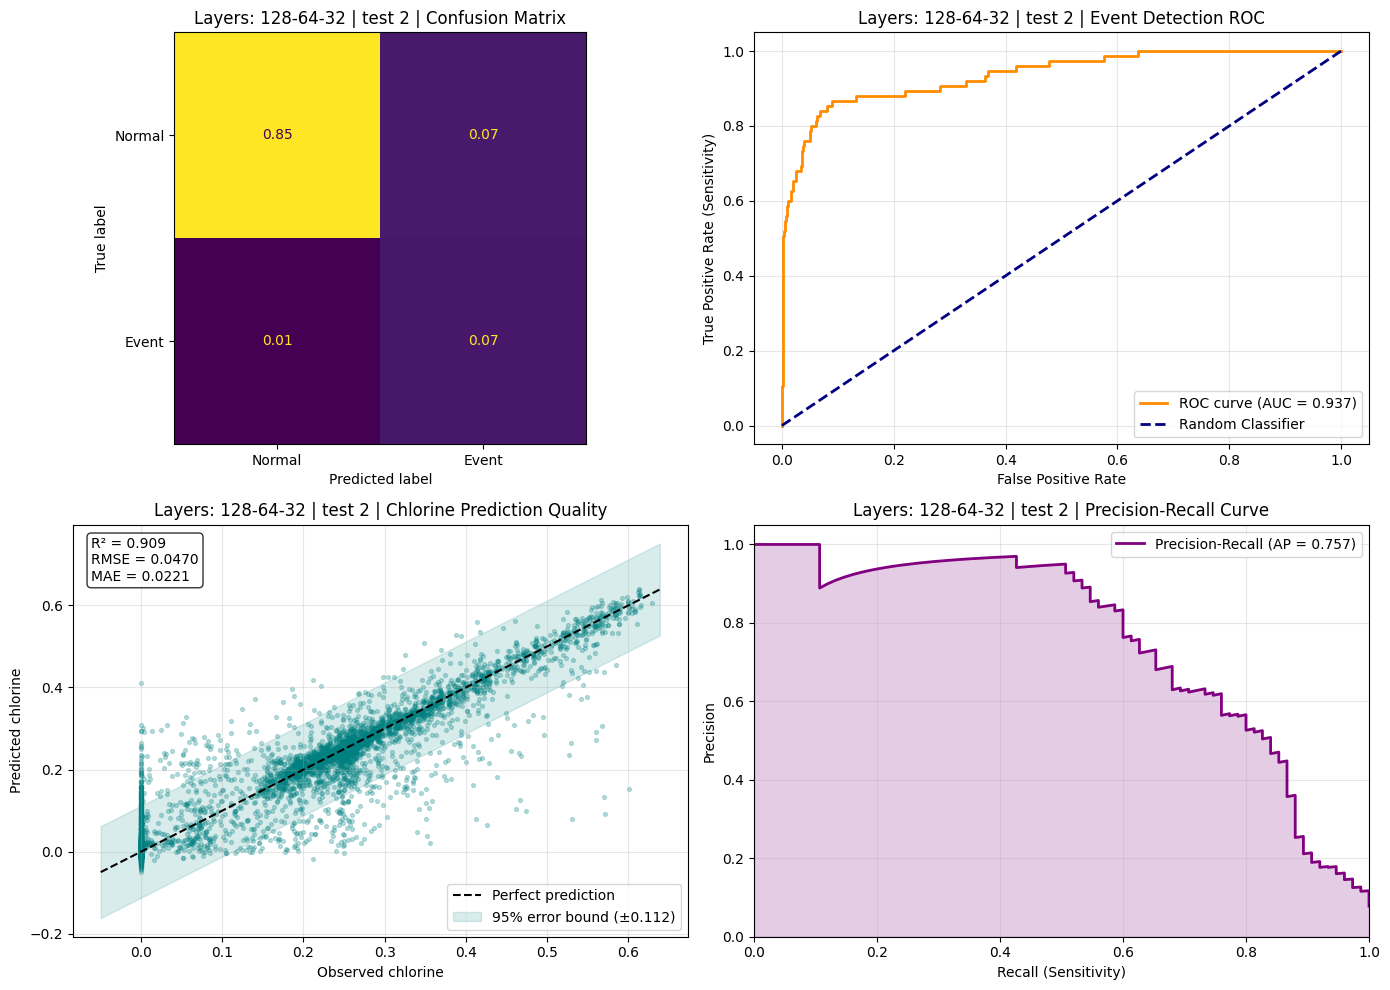

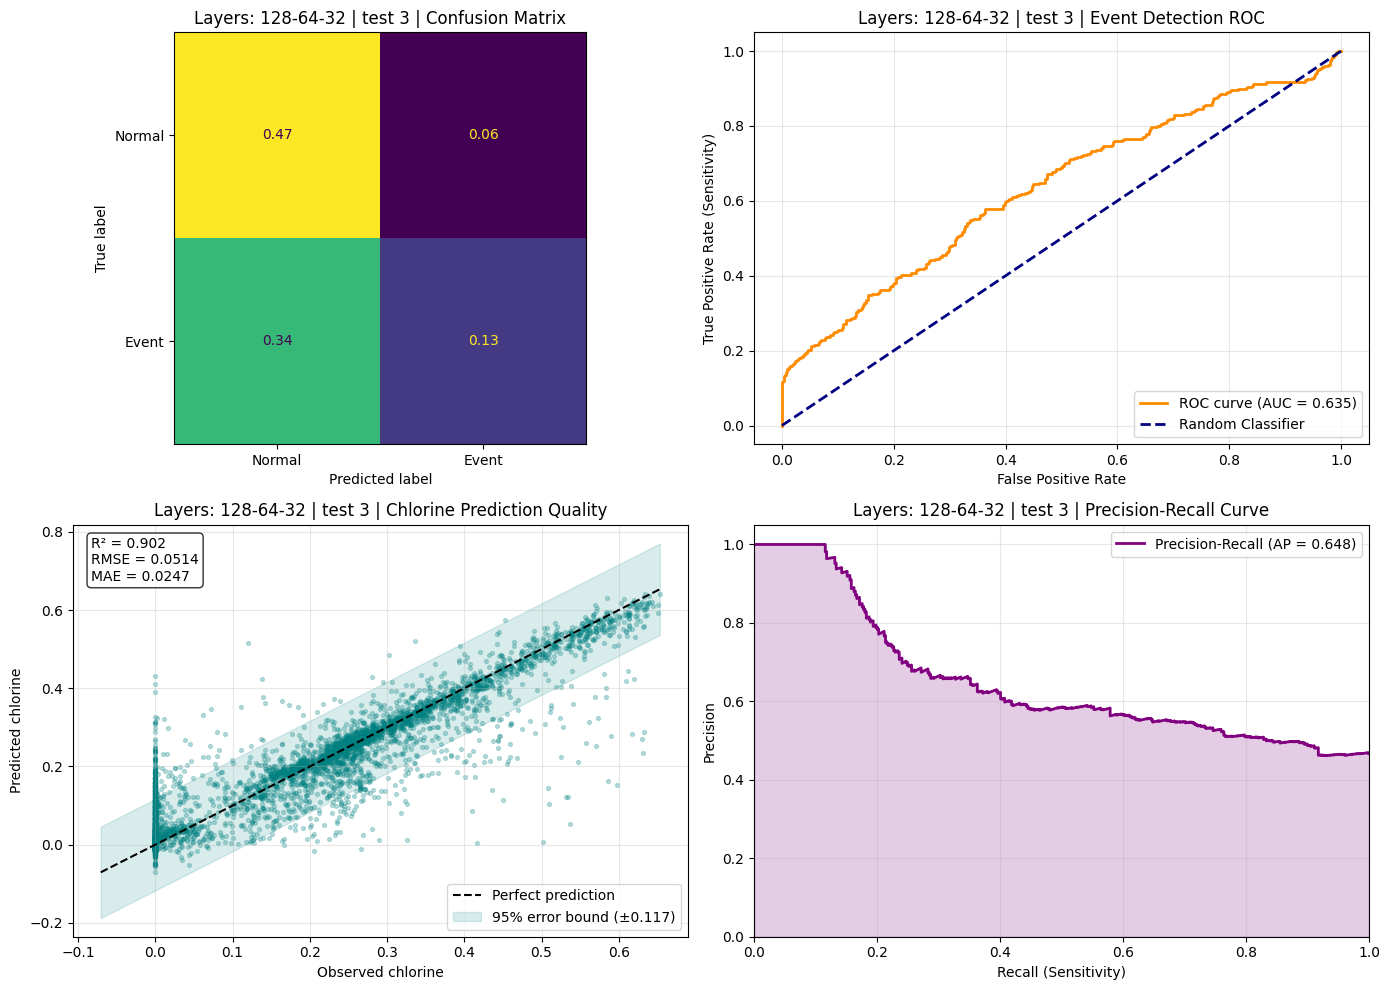

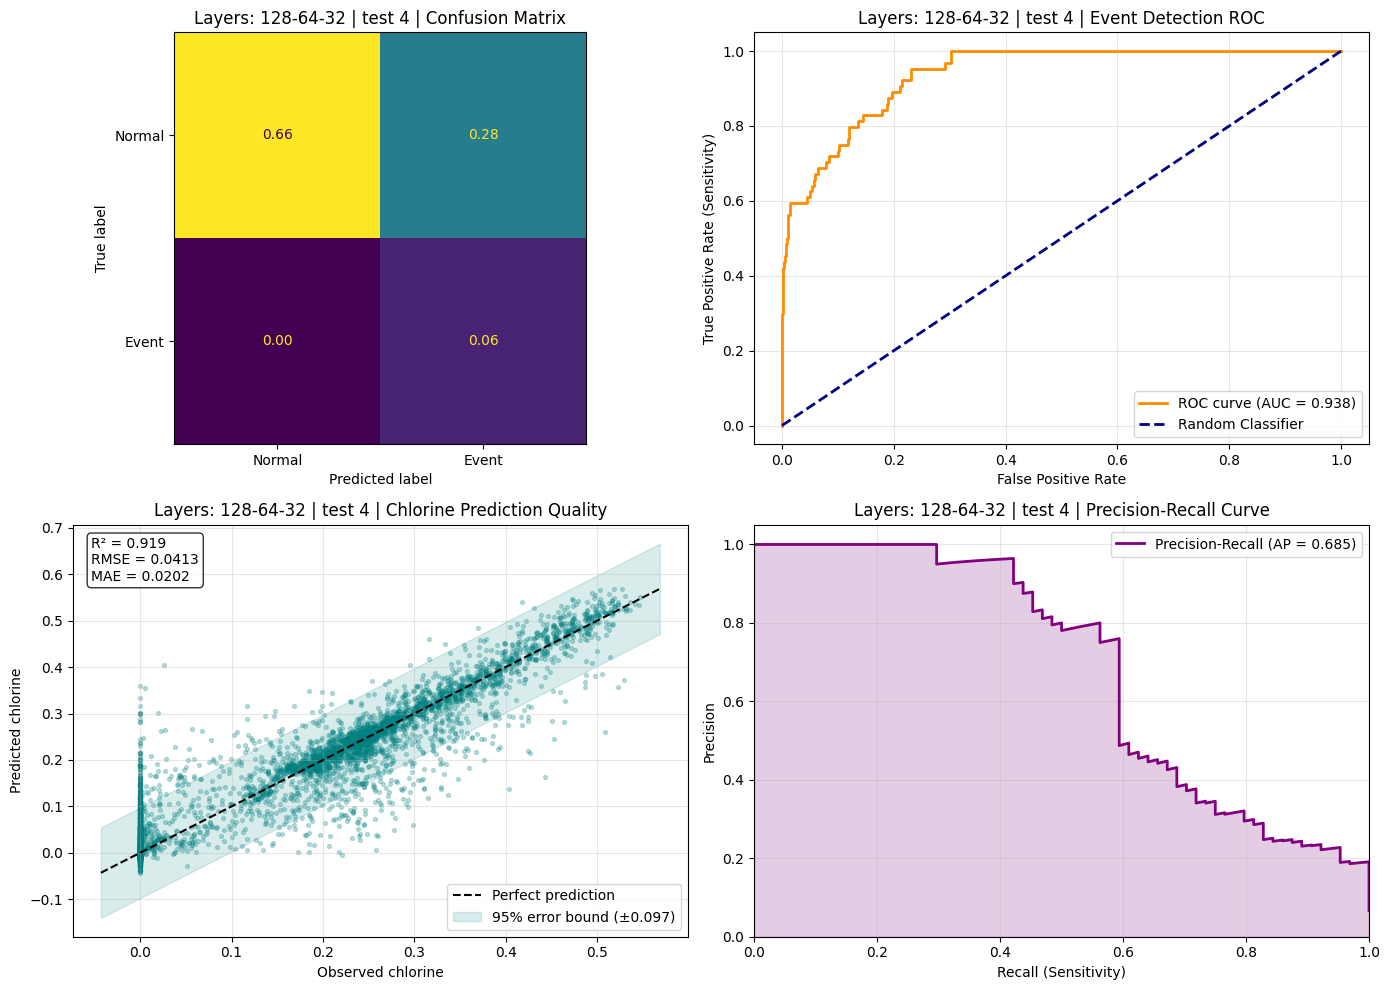

,precision,recall,specificity,balanced_accuracy,accuracy,f1_score,roc_auc,average_precision,false_alarm_rate,detection_latency_seconds,chlorine_mae,chlorine_rmse,chlorine_r2,classifier_hidden_sizes
regressor_hidden_sizes,,,,,,,,,,,,,,
128-64-32,0.396505,0.449695,0.859159,0.654427,0.789282,0.421429,0.728228,0.492366,0.140841,5400.0,0.022738,0.047576,0.90982,32


In [12]:
all_detector_summaries = []
for hidden_sizes in candidate_hidden_sizes:
    hidden_sizes_label = "-".join(map(str, hidden_sizes))
    detector = load_detector(
        directory=f"../../results/ANN/detector_strong_{hidden_sizes_label}",
        device="mps" if torch.backends.mps.is_available() else "cpu",
    )
    results = [detector.detect(path) for path in test_paths]
    metrics = aggregate_evaluation_summary(results)
    metrics["regressor_hidden_sizes"] = hidden_sizes_label
    metrics["classifier_hidden_sizes"] = "-".join(map(str, detector.classifier_hidden_sizes))
    all_detector_summaries.append(metrics)

    display(pd.DataFrame([metrics]).set_index("regressor_hidden_sizes"))
    for i, result in enumerate(results):
        plot_metrics(
            result,
            title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
            chlorine_indices=list(range(result.actual.shape[1])),
        )

all_detector_summaries_df = pd.DataFrame(all_detector_summaries).set_index("regressor_hidden_sizes")
display(all_detector_summaries_df)

classification_columns = [
    "balanced_accuracy", "precision", "recall", "specificity",
    "f1_score", "roc_auc", "average_precision", "false_alarm_rate",
]
regression_columns = ["chlorine_mae", "chlorine_rmse", "chlorine_r2"]